<a href="https://colab.research.google.com/github/AhmedBafuleh/arabic-ssl-ocr-final-project/blob/main/notebooks/01_project_setup_and_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Go to Runtime > Change runtime type > GPU.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4


In [ ]:
!pip install -q datasets transformers jiwer opencv-python matplotlib pandas pillow arabic-reshaper python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_root = "/content/drive/MyDrive/arabic-ssl-ocr-final-project"

folders = [
    "data/raw",
    "data/processed",
    "data/splits",
    "notebooks",
    "src",
    "results/tables",
    "results/graphs",
    "models/baseline",
    "models/ssl",
    "report",
    "presentation",
    "logs"
]

for folder in folders:
    os.makedirs(os.path.join(project_root, folder), exist_ok=True)

print("Project folders created successfully!")
print(project_root)

Project folders created successfully!
/content/drive/MyDrive/arabic-ssl-ocr-final-project


## Load Arabic OCR Dataset

README.md: 0.00B [00:00, ?B/s]

Sample keys: dict_keys(['image', 'text'])
Ground truth text: المتميزة


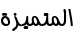

In [ ]:
from datasets import load_dataset

DATASET_NAME = "mssqpi/Arabic-OCR-Dataset"

dataset_stream = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True
)

sample = next(iter(dataset_stream))

print("Sample keys:", sample.keys())
print("Ground truth text:", sample["text"])
display(sample["image"])

Sample 1
Text: المتميزة


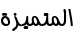

Sample 2
Text: لمساحات


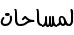

Sample 3
Text: الغذائية


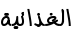

Sample 4
Text: الطولية


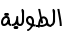

Sample 5
Text: الصانعون


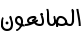

In [ ]:
import matplotlib.pyplot as plt

dataset_stream = load_dataset(
    "mssqpi/Arabic-OCR-Dataset",
    split="train",
    streaming=True
)

for i, sample in enumerate(dataset_stream):
    print(f"Sample {i+1}")
    print("Text:", sample["text"])
    display(sample["image"])

    if i == 4:
        break

## Dataset Inspection

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.77k [00:00<?, ?B/s]

Sample keys: dict_keys(['image', 'text'])
Ground truth text: المتميزة


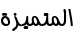

In [ ]:
from datasets import load_dataset

DATASET_NAME = "mssqpi/Arabic-OCR-Dataset"

dataset_stream = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True
)

sample = next(iter(dataset_stream))

print("Sample keys:", sample.keys())
print("Ground truth text:", sample["text"])
display(sample["image"])

## Save Small Dataset Sample

In [ ]:
import os
import pandas as pd
from datasets import load_dataset

DATASET_NAME = "mssqpi/Arabic-OCR-Dataset"

project_root = "/content/drive/MyDrive/arabic-ssl-ocr-final-project"
sample_image_dir = os.path.join(project_root, "data/raw/sample_images")

os.makedirs(sample_image_dir, exist_ok=True)

dataset_stream = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True
)

records = []
MAX_SAMPLES = 200

for i, sample in enumerate(dataset_stream):
    image = sample["image"]
    text = sample["text"]

    image_filename = f"sample_{i:05d}.png"
    image_path = os.path.join(sample_image_dir, image_filename)

    image.save(image_path)

    records.append({
        "image_filename": image_filename,
        "text": text
    })

    if i + 1 >= MAX_SAMPLES:
        break

metadata_path = os.path.join(project_root, "data/raw/sample_metadata.csv")
df = pd.DataFrame(records)
df.to_csv(metadata_path, index=False, encoding="utf-8-sig")

print(f"Saved {len(df)} samples.")
print("Images folder:", sample_image_dir)
print("Metadata file:", metadata_path)
df.head()

Saved 200 samples.
Images folder: /content/drive/MyDrive/arabic-ssl-ocr-final-project/data/raw/sample_images
Metadata file: /content/drive/MyDrive/arabic-ssl-ocr-final-project/data/raw/sample_metadata.csv


,image_filename,text
0,sample_00000.png,المتميزة
1,sample_00001.png,لمساحات
2,sample_00002.png,الغذائية
3,sample_00003.png,الطولية
4,sample_00004.png,الصانعون


In [ ]:
import os
import pandas as pd

project_root = "/content/drive/MyDrive/arabic-ssl-ocr-final-project"

metadata_path = os.path.join(project_root, "data/raw/sample_metadata.csv")
sample_image_dir = os.path.join(project_root, "data/raw/sample_images")

print("Metadata exists:", os.path.exists(metadata_path))
print("Image folder exists:", os.path.exists(sample_image_dir))

df = pd.read_csv(metadata_path)
print("Number of samples:", len(df))
df.head()

Metadata exists: True
Image folder exists: True
Number of samples: 200


,image_filename,text
0,sample_00000.png,المتميزة
1,sample_00001.png,لمساحات
2,sample_00002.png,الغذائية
3,sample_00003.png,الطولية
4,sample_00004.png,الصانعون


Image path: /content/drive/MyDrive/arabic-ssl-ocr-final-project/data/raw/sample_images/sample_00000.png
Image size: (74, 35)
Arabic text: المتميزة


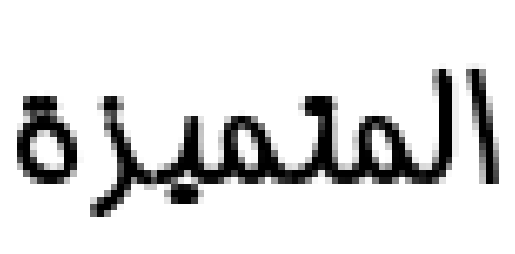

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

first_image_path = os.path.join(sample_image_dir, df.iloc[0]["image_filename"])

img = Image.open(first_image_path)

print("Image path:", first_image_path)
print("Image size:", img.size)
print("Arabic text:", df.iloc[0]["text"])

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
import re

def clean_arabic_text(text):
    """
    Clean Arabic OCR labels.
    Keeps Arabic letters, Arabic numbers, English numbers, and basic spaces.
    Removes strange symbols that may harm OCR training.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove tatweel/kashida
    text = text.replace("ـ", "")

    # Keep Arabic letters, Arabic diacritics, Arabic numbers, English numbers, and spaces
    text = re.sub(r"[^\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF0-9\s]", "", text)

    # Normalize spaces again
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["text"].apply(clean_arabic_text)

df[["image_filename", "text", "clean_text"]].head()

,image_filename,text,clean_text
0,sample_00000.png,المتميزة,المتميزة
1,sample_00001.png,لمساحات,لمساحات
2,sample_00002.png,الغذائية,الغذائية
3,sample_00003.png,الطولية,الطولية
4,sample_00004.png,الصانعون,الصانعون


In [ ]:
from PIL import Image, ImageOps
import numpy as np

processed_image_dir = os.path.join(project_root, "data/processed/images")
os.makedirs(processed_image_dir, exist_ok=True)

TARGET_HEIGHT = 64
TARGET_WIDTH = 512

def preprocess_image(image_path, output_path, target_height=64, target_width=512):
    """
    Preprocess OCR image:
    - Convert to grayscale
    - Resize while keeping aspect ratio
    - Pad to fixed size
    """
    image = Image.open(image_path).convert("L")

    original_width, original_height = image.size

    # Resize while keeping aspect ratio
    new_width = int(original_width * (target_height / original_height))
    image = image.resize((new_width, target_height))

    # If too wide, crop
    if new_width > target_width:
        image = image.crop((0, 0, target_width, target_height))
        new_width = target_width

    # Create white background
    new_image = Image.new("L", (target_width, target_height), color=255)

    # Paste resized image on the left
    new_image.paste(image, (0, 0))

    new_image.save(output_path)

    return output_path


processed_records = []

for index, row in df.iterrows():
    input_path = os.path.join(sample_image_dir, row["image_filename"])
    output_filename = row["image_filename"]
    output_path = os.path.join(processed_image_dir, output_filename)

    preprocess_image(input_path, output_path, TARGET_HEIGHT, TARGET_WIDTH)

    processed_records.append({
        "image_filename": output_filename,
        "text": row["text"],
        "clean_text": row["clean_text"]
    })

processed_df = pd.DataFrame(processed_records)

processed_metadata_path = os.path.join(project_root, "data/processed/processed_metadata.csv")
processed_df.to_csv(processed_metadata_path, index=False, encoding="utf-8-sig")

print("Processed images saved:", len(processed_df))
print("Processed metadata:", processed_metadata_path)
processed_df.head()

Processed images saved: 200
Processed metadata: /content/drive/MyDrive/arabic-ssl-ocr-final-project/data/processed/processed_metadata.csv


,image_filename,text,clean_text
0,sample_00000.png,المتميزة,المتميزة
1,sample_00001.png,لمساحات,لمساحات
2,sample_00002.png,الغذائية,الغذائية
3,sample_00003.png,الطولية,الطولية
4,sample_00004.png,الصانعون,الصانعون


Processed image size: (512, 64)
Clean Arabic text: المتميزة


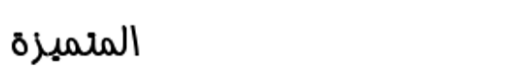

In [ ]:
processed_first_image_path = os.path.join(processed_image_dir, processed_df.iloc[0]["image_filename"])

processed_img = Image.open(processed_first_image_path)

print("Processed image size:", processed_img.size)
print("Clean Arabic text:", processed_df.iloc[0]["clean_text"])

plt.imshow(processed_img, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Remove empty labels
processed_df = processed_df[processed_df["clean_text"].str.len() > 0].reset_index(drop=True)

train_df, temp_df = train_test_split(
    processed_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

splits_dir = os.path.join(project_root, "data/splits")
os.makedirs(splits_dir, exist_ok=True)

train_path = os.path.join(splits_dir, "train.csv")
val_path = os.path.join(splits_dir, "val.csv")
test_path = os.path.join(splits_dir, "test.csv")

train_df.to_csv(train_path, index=False, encoding="utf-8-sig")
val_df.to_csv(val_path, index=False, encoding="utf-8-sig")
test_df.to_csv(test_path, index=False, encoding="utf-8-sig")

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("Saved:")
print(train_path)
print(val_path)
print(test_path)


Train samples: 160
Validation samples: 20
Test samples: 20
Saved:
/content/drive/MyDrive/arabic-ssl-ocr-final-project/data/splits/train.csv
/content/drive/MyDrive/arabic-ssl-ocr-final-project/data/splits/val.csv
/content/drive/MyDrive/arabic-ssl-ocr-final-project/data/splits/test.csv
